# In this notebook, we examine the differences in resulting variational families from two different simplex transforms.

NumPyro and TFP both use a stick-breaking transform when working with a simplex support.
PyMC by default uses a softmax simplex transform that is anchored around the center of the simplex.

In this notebook, we show the following:
* The variational family of diagonal gaussian distributions is not the same in the simplex space from each transform

We will do this by:
* Looking at the difference mathematically between the two transforms
* Showing that the density of a diagonal gaussian when transformed into simplex space via each transform is different
* Showing that a single simplex when transformed back into real space via each of the transforms is *not diagonal after both transforms* 
 

### Why are the two transforms different mathematically?

### The two transforms

Consider a 3-simplex $\theta = (\theta_1,\theta_2,\theta_3)$.
We use a 2-dimensional latent variable $z \in \mathbb{R}^2$.
## The two transforms

We work on the 3-simplex, so $ \theta = (\theta_1,\theta_2,\theta_3) $ satisfies $ \theta_k > 0 $ and $ \theta_1 + \theta_2 + \theta_3 = 1 $.

Both transforms use a 2-dimensional latent variable $ z \in \mathbb{R}^2 $, but they map it to the simplex in different ways.

### PyMC simplex transform: anchored on the first N-1 values in the simplex

PyMC's simplex transform uses the inverse map
$ z_i = \log \theta_i - \frac{1}{K}\sum_{j=1}^K \log \theta_j $
for $ i=1,\dots,K-1 $.

Equivalently, the forward map from latent space to the simplex is:
$ \ell = (z_1,\; z_2,\; -(z_1+z_2)) $
and then
$ \theta = \mathrm{softmax}(\ell) $.

So in the 3-category case,
$ \theta_k = \frac{\exp(\ell_k)}{\sum_{j=1}^3 \exp(\ell_j)} $.

### NumPyro and TFP simplex transform: Centered stick-breaking transform

NumPyro's stick-breaking transform first defines centered break logits
$ x_k = z_k - \log(K-k) $
for $ k=1,\dots,K-1 $.

Then it converts them to break fractions
$ v_k = \sigma(x_k) = \frac{1}{1 + e^{-x_k}} $.

For $ K=3 $, the simplex coordinates are
$ \theta_1 = v_1 $,
$ \theta_2 = v_2(1-v_1) $,
and
$ \theta_3 = (1-v_1)(1-v_2) $.

### Mathematically what's different?

Say we have a smooth transform $ T : \mathbb{R}^{K-1} \to \Delta^{K-1} $ from latent space to the simplex and set $ z \sim \mathcal{N}(\mu,\Sigma) $ and define $ \theta = T(z) $.

If we linearize $T$ around $ \mu $ via a taylor expansion:
$ T(z) \approx T(\mu) + J(\mu)(z-\mu) $,
where
$ J(\mu) $ is the Jacobian at $ \mu $.

Approximating locally, we have
$$
 \mathrm{Cov}[\theta] \approx J(\mu)\,\Sigma\,J(\mu)^\top.
 $$

Even if $\Sigma$ is diagonal, the induced simplex covariance above depends on the jacobian.

So the covariance of $\theta$ from each transform is different if the Jacobians are different.


In [1]:
# the code from pymc defining the simplex transform: https://www.pymc.io/projects/docs/en/latest/_modules/pymc/logprob/transforms.html#SimplexTransform

# class SimplexTransform(Transform):
#     name = "simplex"


#     def forward(self, value, *inputs):
#         value = pt.as_tensor(value)
#         log_value = pt.log(value)
#         N = value.shape[-1].astype(value.dtype)
#         shift = pt.sum(log_value, -1, keepdims=True) / N
#         return log_value[..., :-1] - shift

#     def backward(self, value, *inputs):
#         value = pt.concatenate([value, -pt.sum(value, -1, keepdims=True)], axis=-1)
#         exp_value_max = pt.exp(value - pt.max(value, -1, keepdims=True))
#         return exp_value_max / pt.sum(exp_value_max, -1, keepdims=True)

#     def log_jac_det(self, value, *inputs):
#         value = pt.as_tensor(value)
#         N = value.shape[-1] + 1
#         N = N.astype(value.dtype)
#         sum_value = pt.sum(value, -1, keepdims=True)
#         value_sum_expanded = value + sum_value
#         value_sum_expanded = pt.concatenate([value_sum_expanded, pt.zeros_like(sum_value)], -1)
#         logsumexp_value_expanded = pt.logsumexp(value_sum_expanded, -1, keepdims=True)
#         res = pt.log(N) + (N * sum_value) - (N * logsumexp_value_expanded)
#         return pt.sum(res, -1)

In [2]:
# the code from the numpyro stickbreaking transform:

# class StickBreakingTransform(ParameterFreeTransform[NonScalarArray]):
#     domain = constraints.real_vector
#     codomain = constraints.simplex

#     def __call__(self, x: NonScalarArray) -> NonScalarArray:
#         # we shift x to obtain a balanced mapping (0, 0, ..., 0) -> (1/K, 1/K, ..., 1/K)
#         x = x - jnp.log(x.shape[-1] - jnp.arange(x.shape[-1]))
#         # convert to probabilities (relative to the remaining) of each fraction of the stick
#         z = _clipped_expit(x)
#         z1m_cumprod = jnp.cumprod(1 - z, axis=-1)
#         pad_width = [(0, 0)] * x.ndim
#         pad_width[-1] = (0, 1)
#         z_padded = jnp.pad(z, pad_width, mode="constant", constant_values=1.0)
#         pad_width = [(0, 0)] * x.ndim
#         pad_width[-1] = (1, 0)
#         z1m_cumprod_shifted = jnp.pad(
#             z1m_cumprod, pad_width, mode="constant", constant_values=1.0
#         )
#         return z_padded * z1m_cumprod_shifted

#     def _inverse(self, y: NonScalarArray) -> NonScalarArray:
#         y_crop = y[..., :-1]
#         z1m_cumprod = jnp.clip(1 - jnp.cumsum(y_crop, axis=-1), jnp.finfo(y.dtype).tiny)
#         # hence x = logit(z) = log(z / (1 - z)) = y[::-1] / z1m_cumprod
#         x = jnp.log(y_crop / z1m_cumprod)
#         return x + jnp.log(x.shape[-1] - jnp.arange(x.shape[-1]))

#     def log_abs_det_jacobian(
#         self,
#         x: NonScalarArray,
#         y: NonScalarArray,
#         intermediates: Optional[PyTree] = None,
#     ) -> NumLike:
#         # Ref: https://mc-stan.org/docs/2_19/reference-manual/simplex-transform-section.html
#         # |det|(J) = Product(y * (1 - sigmoid(x)))
#         #          = Product(y * sigmoid(x) * exp(-x))
#         x = x - jnp.log(x.shape[-1] - jnp.arange(x.shape[-1]))
#         return jnp.sum(jnp.log(y[..., :-1]) + (log_sigmoid(x) - x), axis=-1)

#     def forward_shape(self, shape: tuple[int, ...]) -> tuple[int, ...]:
#         if len(shape) < 1:
#             raise ValueError("Too few dimensions on input")
#         return shape[:-1] + (shape[-1] + 1,)

#     def inverse_shape(self, shape: tuple[int, ...]) -> tuple[int, ...]:
#         if len(shape) < 1:
#             raise ValueError("Too few dimensions on input")
#         return shape[:-1] + (shape[-1] - 1,)

#### Note: from the code from pymc and numpyro, we can see that they both center at equal coords $(1/3, 1/3, 1/3)$ in $R^d$

In [3]:
# set up code functions and such 
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from modulars.utils import (
    anchored_softmax_simplex_forward,
    stickbreaking_simplex_forward,
    anchored_simplex_inverse,
    stickbreaking_simplex_inverse,
)
# we've already defined these in utils.py to do our
# trajectory plotting, so we can use them again to 
# look at the differences in transformations.

np.set_printoptions(suppress=True, precision=4)


In [4]:
A = np.array([0.0, 0.0])
B = np.array([1.0, 0.0])
C = np.array([0.5, np.sqrt(3.0) / 2.0])
simplex_to_xy_matrix = np.stack([A, B, C], axis=1)
# these are the label locations

def simplex_to_xy(theta):
    # to allow for xy plotting of a simplex point
    theta = np.asarray(theta, dtype=float)
    if theta.ndim == 1:
        theta = theta[None, :]
    return theta @ simplex_to_xy_matrix.T

def xy_to_bary(xy):
    # to allow for barycentric coordinate plotting of an xy point
    xy = np.asarray(xy, dtype=float)
    x = xy[..., 0]
    y = xy[..., 1]

    theta3 = y / C[1]
    theta2 = x - 0.5 * theta3
    theta1 = 1.0 - theta2 - theta3

    return np.stack([theta1, theta2, theta3], axis=-1)


def inside_simplex(xy, tol=1e-10):
    # check if an xy point is inside the simplex with a tolerance for numerical issues
    bary = xy_to_bary(xy)
    return np.all(bary >= -tol, axis=-1) & np.all(bary <= 1.0 + tol, axis=-1)


def draw_simplex(ax, show_labels=True):
    # to draw the simplex triangle and maybe label the corners
    pts = np.vstack([A, B, C, A])
    ax.plot(pts[:, 0], pts[:, 1], color="black", lw=1.2)

    if show_labels:
        ax.text(A[0] - 0.03, A[1] - 0.03, r"$\theta_1$", ha="right", va="top", fontsize=12)
        ax.text(B[0] + 0.03, B[1] - 0.03, r"$\theta_2$", ha="left", va="top", fontsize=12)
        ax.text(C[0], C[1] - 0.01, r"$\theta_3$", ha="center", va="bottom", fontsize=12)

    ax.set_aspect("equal")
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, np.sqrt(3.0) / 2.0 + 0.04)
    ax.set_xticks([])
    ax.set_yticks([])


def simplex_kde_contour(ax, theta_samples, color, label, quantiles=(0.5, 0.6, 0.7, 0.8, 0.9, 0.95), lw=1.5):
    xy = simplex_to_xy(theta_samples)
    kde = gaussian_kde(xy.T)

    gx = np.linspace(-0.02, 1.02, 240)
    gy = np.linspace(-0.02, np.sqrt(3.0) / 2.0 + 0.02, 220)
    XX, YY = np.meshgrid(gx, gy)

    grid = np.column_stack([XX.ravel(), YY.ravel()])
    mask = inside_simplex(grid)

    ZZ = np.full(grid.shape[0], np.nan)
    ZZ[mask] = kde(grid[mask].T)
    ZZ = ZZ.reshape(XX.shape)

    valid = ZZ[~np.isnan(ZZ)]
    levels = np.quantile(valid, quantiles)
    levels = np.unique(levels)

    if len(levels) < 2:
        levels = np.linspace(valid.min(), valid.max(), 4)[1:]

    ax.contour(XX, YY, ZZ, levels=levels, colors=color, linewidths=lw)
    ax.plot([], [], color=color, lw=lw, label=label)


def cov_to_corr(cov):
    cov = np.asarray(cov, dtype=float)
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    denom = np.outer(std, std)
    corr = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)
    return corr, std


def offdiag_ratio(corr):
    corr = np.asarray(corr, dtype=float)
    offdiag = corr - np.eye(corr.shape[0])
    return np.linalg.norm(offdiag, ord="fro") / np.sqrt(corr.shape[0] * (corr.shape[0] - 1))


def sample_gaussian(mu, std, n_samples=60_000, seed=0):
    rng = np.random.default_rng(seed)
    return rng.normal(
        loc=np.asarray(mu, dtype=float),
        scale=np.asarray(std, dtype=float),
        size=(n_samples, len(mu)))

def transform_samples(forward_fn, gaussian_samples, n_cats=3):
    return forward_fn(gaussian_samples, n_cats=n_cats)


def numerical_jacobian(forward_fn, z0, eps=1e-5):
    z0 = np.asarray(z0, dtype=float)
    f0 = forward_fn(z0, n_cats=3)[0]

    J = np.zeros((f0.size, z0.size), dtype=float)
    for j in range(z0.size):
        step = np.zeros_like(z0)
        step[j] = eps

        fp = forward_fn(z0 + step, n_cats=3)[0]
        fm = forward_fn(z0 - step, n_cats=3)[0]

        J[:, j] = (fp - fm) / (2.0 * eps)

    return J


def plot_cov_ellipse(ax, mean_xy, cov_xy, color, label=None, quantiles=(0.5, 0.6, 0.7, 0.8, 0.9, 0.95), lw=2.0):
    """
    Plot Gaussian covariance ellipses as probability quantile contours.
    """
    vals, vecs = np.linalg.eigh(cov_xy)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    vals = np.clip(vals, 0.0, None)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    for i, q in enumerate(quantiles):
        r2 = chi2.ppf(q, df=2)

        width = 2.0 * np.sqrt(r2 * vals[0])
        height = 2.0 * np.sqrt(r2 * vals[1])

        ellipse = Ellipse(
            xy=mean_xy,
            width=width,
            height=height,
            angle=angle,
            fill=False,
            edgecolor=color,
            lw=lw if i == len(quantiles) - 1 else 1.4,
            alpha=0.9 if i == len(quantiles) - 1 else 0.6,
            linestyle="-",
            label=label if i == len(quantiles) - 1 else None,
        )
        ax.add_patch(ellipse)

In [5]:
# run flags for the heavier notebook sections
RUN_EARLY_TRANSFORM_SECTION = False
RUN_INVERSE_DIAGNOSTIC = False
RUN_FINAL_DIRICHLET_TOYS = True

print("Run flags set. By default, Run All skips the early exploratory sections and keeps the final Dirichlet toy section on.")


Run flags set. By default, Run All skips the early exploratory sections and keeps the final Dirichlet toy section on.


## Let's show the difference in transforming from a diagonal gaussian to a simplex.

In the following, we:
* choose a diagonal gaussian
* transform the gaussian via each transform
* look at the resulting simplices


In [6]:
if RUN_EARLY_TRANSFORM_SECTION:
    # set up the transforms
    transform_center = np.array([1/3, 1/3, 1/3]) # we use this in plotting

    # choose same diagonal gaussian for both transforms
    std = np.array([0.1, 0.8])
    mu = np.zeros(2)
    Sigma = np.diag(std ** 2)

    # we will use the same gaussian samples for both transforms to compare
    gaussian_samples = sample_gaussian(mu, std, n_samples=100_000, seed=0)

    # transform the samples through both transforms
    pymc_simplex_samples = transform_samples(anchored_softmax_simplex_forward, gaussian_samples, n_cats=3)
    stick_simplex_samples = transform_samples(stickbreaking_simplex_forward, gaussian_samples, n_cats=3)

    print("The resulting distribution statistics (mean, std) of the transformed samples are:")
    print()
    print("mean of pymc transformed gaussian samples:\n", pymc_simplex_samples.mean(axis=0))
    print("mean of stick-breaking transformed gaussian samples:\n", stick_simplex_samples.mean(axis=0))
    print()
    print("std of pymc anchored simplex samples:\n", pymc_simplex_samples.std(axis=0))
    print("std of stick-breaking simplex samples:\n", stick_simplex_samples.std(axis=0))
else:
    print("Skipping the early diagonal-Gaussian transform comparison. Set RUN_EARLY_TRANSFORM_SECTION = True to run it.")

Skipping the early diagonal-Gaussian transform comparison. Set RUN_EARLY_TRANSFORM_SECTION = True to run it.


In [7]:
if RUN_EARLY_TRANSFORM_SECTION:
    # here we will visualize the resulting simplex distributions
    # that come from the *same* gaussian samples

    fig, axes = plt.subplots(3, 1, figsize=(15, 16), constrained_layout=True)
    for ax in axes: draw_simplex(ax);

    simplex_kde_contour(
        axes[0],
        pymc_simplex_samples,
        color="tab:blue",
        label="PyMC transform",
    )
    axes[0].scatter(*simplex_to_xy(transform_center)[0], color="black", s=30, zorder=5)
    axes[0].set_title("PyMC transform")

    simplex_kde_contour(
        axes[1],
        stick_simplex_samples,
        color="tab:red",
        label="Stick-breaking transform",
    )
    axes[1].scatter(*simplex_to_xy(transform_center)[0], color="black", s=30, zorder=5)
    axes[1].set_title("Stick-breaking transform")

    simplex_kde_contour(
        axes[2],
        pymc_simplex_samples,
        color="tab:blue", label="PyMC transform",
    )
    simplex_kde_contour(
        axes[2],
        stick_simplex_samples,
        color="tab:red",
        label="Stick-breaking transform",
    )
    axes[2].scatter(*simplex_to_xy(transform_center)[0], color="black", s=30, zorder=5)
    axes[2].set_title("Overlay of both transforms")

    for ax in axes: ax.legend(loc="lower left", fontsize=9, framealpha=0.9);
    print("The plotted quantiles are: 50%, 60%, 70%, 80%, 90%, and 95% quantiles of the KDE contours.")
    plt.show()
else:
    print("Skipping the early simplex contour plots. Set RUN_EARLY_TRANSFORM_SECTION = True to run them.")

Skipping the early simplex contour plots. Set RUN_EARLY_TRANSFORM_SECTION = True to run them.


## Now we will look at whether diagonal gaussians transformed via one transform correspond to diagonal gaussians transformed via the other transform.

### Here's the idea:

Lets say that $\mathcal{T}_1$ is the image of transforming the mean field variational family via transform $T_1$ and $\mathcal{T}_2$ is the image of transforming the mean field variational family via transform $T_2$. WLOG, it does not matter which is which for this high level idea. Essentially, the $\mathcal{T}_1, \mathcal{T}_2$ images are the set of all simplex distributions that can be created by transforming a mean field gaussian via the respective transform.

We're interested in whether or not $\mathcal{T}_1 = \mathcal{T}_2$. 

- If they were the same, then this would mean that for every simplex distribution $\theta$ created by transform $T_1$, there would be a mean field gaussian $X$ such that $\theta = T_1(X)$ and there would be a (not necessarily the same) mean field gaussian $X'$ such that $\theta = T_2(X')$. This would mean that both transforms would be able to (theoretically) find the same "best" simplex variational approximation.

- We're going to show this is not the case by finding an exception. We're going to show, empirically below, that there exists a simplex distributon $\theta\in\mathcal{T}_1$ such that $\theta\notin\mathcal{T}_2$, i.e., $\theta$ is in the image of the mean field variational family transformed by transform $T_1$ but is not in the image of transform $T_2$. We will actually show that there is also a simplex distribution in the image of $T_2$ that is not in the image of $T_1$, thus demonstrating that the neither image is a subset of the other and both contain distributions not in the image of the other.

- If we can conclude that $\mathcal{T}_1\neq\mathcal{T}_2$, $\mathcal{T}_1\not\subseteq\mathcal{T}_2$, and $\mathcal{T}_1\not\supseteq\mathcal{T}_2$ (non-equal and both are non-subsets of the other), then we can make the following conclusion:

>It is possible that the best variational approximation of a particular dirichlet posterior using transform $T_1$ is better than the best variational approximation of the same posterior using transform $T_2$ (and vice versa WLOG).

### So how do we empirically show this?
We've already shown it theoretically at the top of this notebook.

In the following diagnostic/plot/demonstration, we will choose a particular diagonal gaussian $X$. Then we will approximate $T_1(X)$ and $T_2(X)$ by drawing 5 million points $Y = [y_1, \ldots]$ where $y_i\stackrel{i.i.d}{\sim}X$ and representing $T_1(X)$ via the samples $T_1(Y) = [T_1(y_1), \ldots]$ and similarly for $T_2$.

Now, we will first sanity check that $T_1(Y)$ and $T_2(Y)$ empirically are within the images $\mathcal{T}_1, \mathcal{T}_2$, respectively, by plotting $T_1^{-1}(T_1(Y))$ and $T_2^{-1}(T_2(Y))$ which should both look like diagonal gaussians.

Next, we will show that $T_1(Y)$ is not within the image $\mathcal{T}_2$ by plotting $T_2^{-1}(T_1(Y))$ and vice versa with $T_2(Y)$. The respective plots visualize what distribution of points would transform via $T_2$ into $T_1(Y)$ and vice versa. Since neither distribution of points is empirically diagonal gaussian, we can conclude that the simplex distributions represented by $T_1(Y)\notin\mathcal{T}_2$ and $T_2(Y)\notin\mathcal{T}_1$ are not in the other image and thus (empirically) we have shown the non-equality and non-subset of the images.

In the plots below, we can read them via:

- **Rows** tell us which simplex samples we start from.
  - Top row: simplex samples produced by the PyMC anchored transform.
  - Bottom row: simplex samples produced by the stick-breaking transform.
- **Columns** tell us which inverse map we apply to those simplex samples.
  - Left column: invert back using the PyMC inverse.
  - Right column: invert back using the stick-breaking inverse.

How to read the point clouds:
- An approximately axis-aligned elliptical blob of points is a **diagonal Gaussian** in that coordinate system.
- Anything else is not, and we are more and more confident in this the more samples we have and the more non-diagonal it looks.
- The reported `offdiag ratio` arises from the empirical correlation matrix of the point cloud and is the ratio of the off-diagonal entries to the diagonal entries. The greater this value, the less diagonal the samples are.



In [8]:
if RUN_INVERSE_DIAGNOSTIC:
    from matplotlib.colors import LogNorm
    # we take samples from one gaussian and transform them through both transforms 
    many_gaussian_samples = sample_gaussian(
        np.zeros(2), np.array([0.1, 0.8]), 
        n_samples=5_000_000, seed=0)

    # transform the samples through both transforms
    many_pymc_simplex_samples = transform_samples(anchored_softmax_simplex_forward, many_gaussian_samples, n_cats=3)
    many_stick_simplex_samples = transform_samples(stickbreaking_simplex_forward, many_gaussian_samples, n_cats=3)

    # we can use our diagonal gaussian samples from earlier since 
    # we know that they are actually centered identically in the 
    # simplex under both transforms 
    theta_samples = [
        ('PyMC transformed samples', many_pymc_simplex_samples),
        ('Stick-breaking transformed samples', many_stick_simplex_samples),
    ]
    inverse_fns = [
        ('PyMC inverse function', anchored_simplex_inverse),
        ('Stick-breaking inverse function', stickbreaking_simplex_inverse),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
    last_im = None
    # let's apply both inverse transforms to both sets of simplex samples.
    # in order for the transforms to have the same variational family,
    # we should see that all four combinations of inverse transform 
    # and simplex samples give approx a diagonal gaussian 
    for i, (sample_label, simplex_samples) in enumerate(theta_samples):
        for j, (inverse_label, inverse_fn) in enumerate(inverse_fns):
            inverted_samples = inverse_fn(simplex_samples)
            inverted_corr = np.corrcoef(inverted_samples, rowvar=False)
            ratio = offdiag_ratio(inverted_corr)

            # plot the histogram of the inverted samples to see if they look diagonal gaussian
            axes[i, j].hist2d(
                inverted_samples[:, 0], inverted_samples[:, 1],
                bins=120, density=True, cmap="Purples",
            )

            axes[i, j].set_title(f'{sample_label}\n{inverse_label}\noffdiag ratio' + r'$\approx$' + f' {ratio:.3f}')

            print(f"{sample_label} in {inverse_label}")
            print("correlation matrix:")
            print(inverted_corr)
            print("offdiag ratio:", ratio)
            print()

    plt.show()
else:
    print("Skipping the inverse-diagnostic section. Set RUN_INVERSE_DIAGNOSTIC = True to run it.")


Skipping the inverse-diagnostic section. Set RUN_INVERSE_DIAGNOSTIC = True to run it.


Note that both transforms may agree on the same center point of the simplex, but they stretch and bend neighborhoods around that point differently. The last plots make that geometric difference visible in the latent space where the variational family is actually defined.


## Two actual Dirichlet toy posteriors

To keep the end of the notebook tied to the conjugate setting, we finish with two **actual Dirichlet-multinomial posteriors**. For each case, we print the exact conjugate posterior and compare the two PyMC variational fits using the **terminal ADVI loss**.

Both PyMC fits below still use the **Adam optimizer**, **100 Monte Carlo samples during ADVI training**, and **50,000 iterations**. The exact posterior marginals are plotted as the corresponding **Beta marginals**, while the variational marginals are plotted as **Normal approximations built from the reported simplex-space mean and standard deviation**.


In [9]:
import pymc as pm
import pytensor
from scipy.stats import beta, norm

from modulars.distributions import lda_posterior_shared_theta
from modulars.pymc_rr_test import StickBreakingSimplexTransform

pytensor.config.cxx = "/usr/bin/clang++"


def print_rows_table(rows, float_digits=4):
    if len(rows) == 0:
        print("[]")
        return

    columns = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for col in columns:
            value = row[col]
            if isinstance(value, float):
                formatted.append(f"{value:.{float_digits}f}")
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for col_idx, col in enumerate(columns):
        widths.append(max(len(col), max(len(row[col_idx]) for row in formatted_rows)))

    header = " | ".join(col.ljust(widths[i]) for i, col in enumerate(columns))
    divider = "-+-".join("-" * widths[i] for i in range(len(columns)))
    print(header)
    print(divider)
    for row in formatted_rows:
        print(" | ".join(row[i].ljust(widths[i]) for i in range(len(columns))))


def build_toy_pymc_dirichlet_model(alpha_prior, n_vec, obs_counts, simplex_transform="default"):
    with pm.Model() as model:
        if simplex_transform == "default":
            theta = pm.Dirichlet("theta", a=alpha_prior)
        elif simplex_transform == "stickbreaking":
            theta = pm.Dirichlet(
                "theta",
                a=alpha_prior,
                default_transform=StickBreakingSimplexTransform(),
            )
        else:
            raise ValueError("simplex_transform must be 'default' or 'stickbreaking'")

        pm.Multinomial("y", n=n_vec, p=theta, observed=np.array(obs_counts))

    return model


def fit_dirichlet_toy_case(
    case,
    simplex_transform,
    n_iters=50_000,
    n_draws=40_000,
):
    alpha_prior = np.array(case["alpha_prior"], dtype=np.float32)
    obs_counts = np.array(case["obs_counts"], dtype=int)
    n_vec = np.sum(obs_counts, axis=1).astype(int)

    true_post = lda_posterior_shared_theta(obs_counts, alpha_prior)
    exact_alpha_post = np.asarray(true_post["alpha_post"], dtype=float)
    exact_mean = np.asarray(true_post["mean_post"], dtype=float)

    model = build_toy_pymc_dirichlet_model(
        alpha_prior=alpha_prior,
        n_vec=n_vec,
        obs_counts=obs_counts,
        simplex_transform=simplex_transform,
    )

    advi = pm.ADVI(model=model, random_seed=case["vi_seed"])
    tracker = pm.callbacks.Tracker(
        mean=advi.approx.mean.eval,
        cov=advi.approx.cov.eval,
    )
    approx = advi.fit(
        n=n_iters,
        callbacks=[tracker],
        progressbar=False,
        obj_n_mc=100,
        obj_optimizer=pm.adam(),
    )

    final_loc = np.asarray(tracker["mean"][-1], dtype=float)
    final_cov = np.asarray(tracker["cov"][-1], dtype=float)
    rng = np.random.default_rng(case["transport_seed"])
    z = rng.multivariate_normal(final_loc, final_cov, size=int(n_draws))

    if simplex_transform == "default":
        theta_draws = anchored_softmax_simplex_forward(z, n_cats=3)
    else:
        theta_draws = stickbreaking_simplex_forward(z, n_cats=3)

    approx_mean = theta_draws.mean(axis=0)
    approx_cov = np.cov(theta_draws, rowvar=False)
    exact_draws = rng.dirichlet(exact_alpha_post, size=int(n_draws))

    return {
        "final_loss": float(approx.hist[-1]),
        "latent_loc": final_loc,
        "latent_cov": final_cov,
        "theta_draws": theta_draws,
        "approx_mean": approx_mean,
        "approx_cov": approx_cov,
        "obs_counts": obs_counts,
        "exact_alpha_post": exact_alpha_post,
        "exact_mean": exact_mean,
        "exact_draws": exact_draws,
    }


Running Middle-heavy posterior ...


Finished [100%]: Average Loss = 5.0189
Finished [100%]: Average Loss = 4.8524


Running Default-favored terminal-loss posterior ...


Finished [100%]: Average Loss = 4.0918
Finished [100%]: Average Loss = 4.0857


Middle-heavy posterior
alpha_prior: [0.3, 3.0, 0.3]
observed counts:
[[1 7 0]
 [1 7 0]
 [0 8 0]]
vi_seed: 5
underlying posterior: Dirichlet(alpha=[ 2.3 25.   0.3])
posterior mean: [0.0833 0.9058 0.0109]
ADVI iterations: 50000

transform      | terminal_loss
---------------+--------------
PyMC default   | 4.9260       
Stick-breaking | 4.8078       
lower terminal loss: Stick-breaking



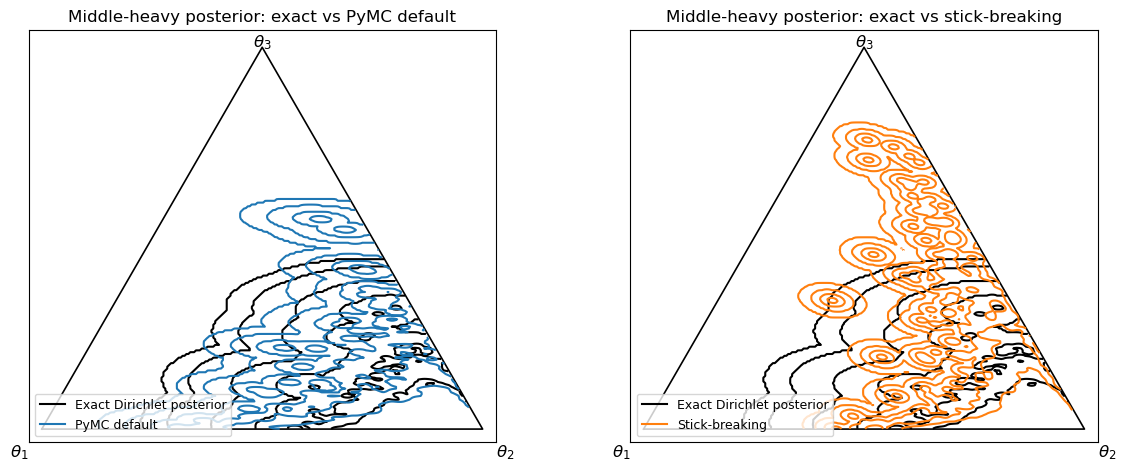

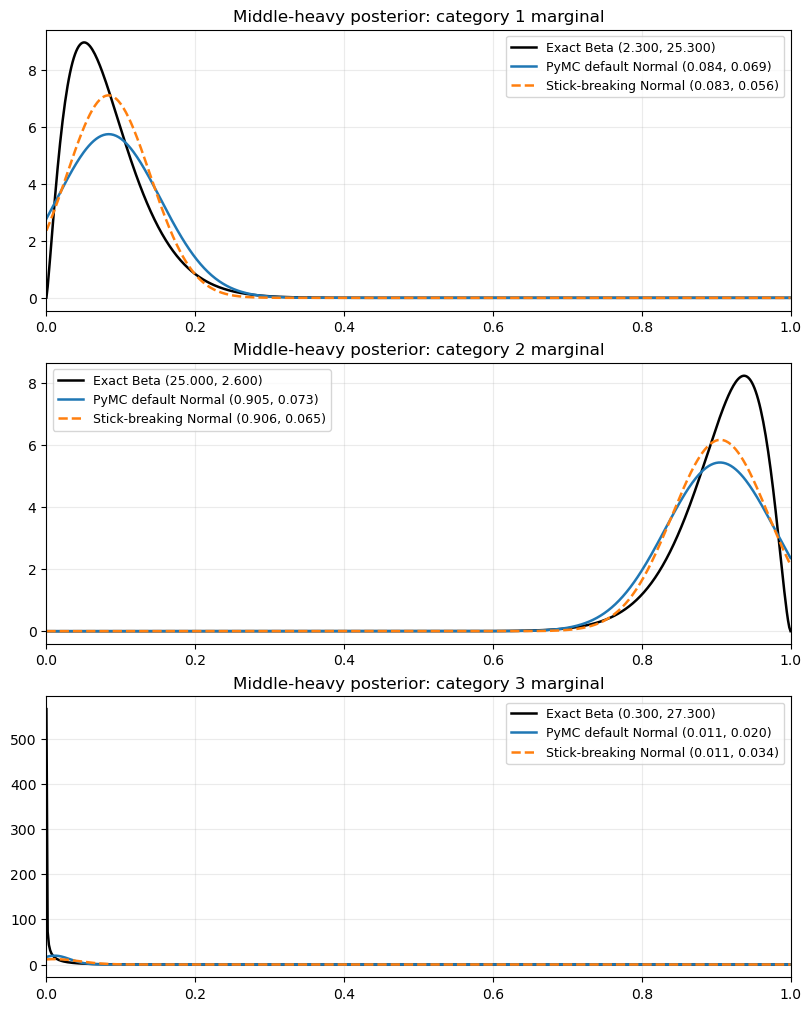

Default-favored terminal-loss posterior
alpha_prior: [2.0, 2.0, 1.0]
observed counts:
[[0 8 0]]
vi_seed: 2
underlying posterior: Dirichlet(alpha=[ 2. 10.  1.])
posterior mean: [0.1538 0.7692 0.0769]
ADVI iterations: 50000

transform      | terminal_loss
---------------+--------------
PyMC default   | 4.0384       
Stick-breaking | 4.0530       
lower terminal loss: PyMC default



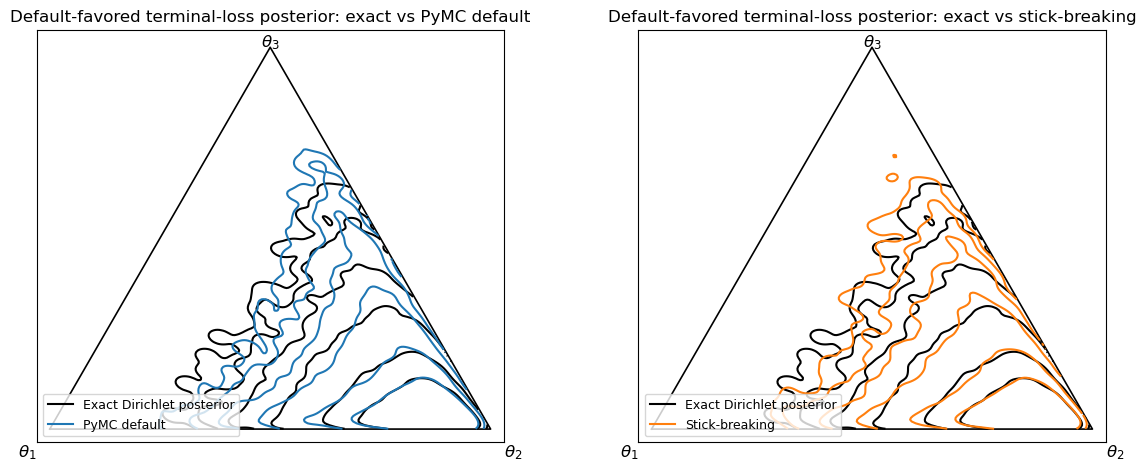

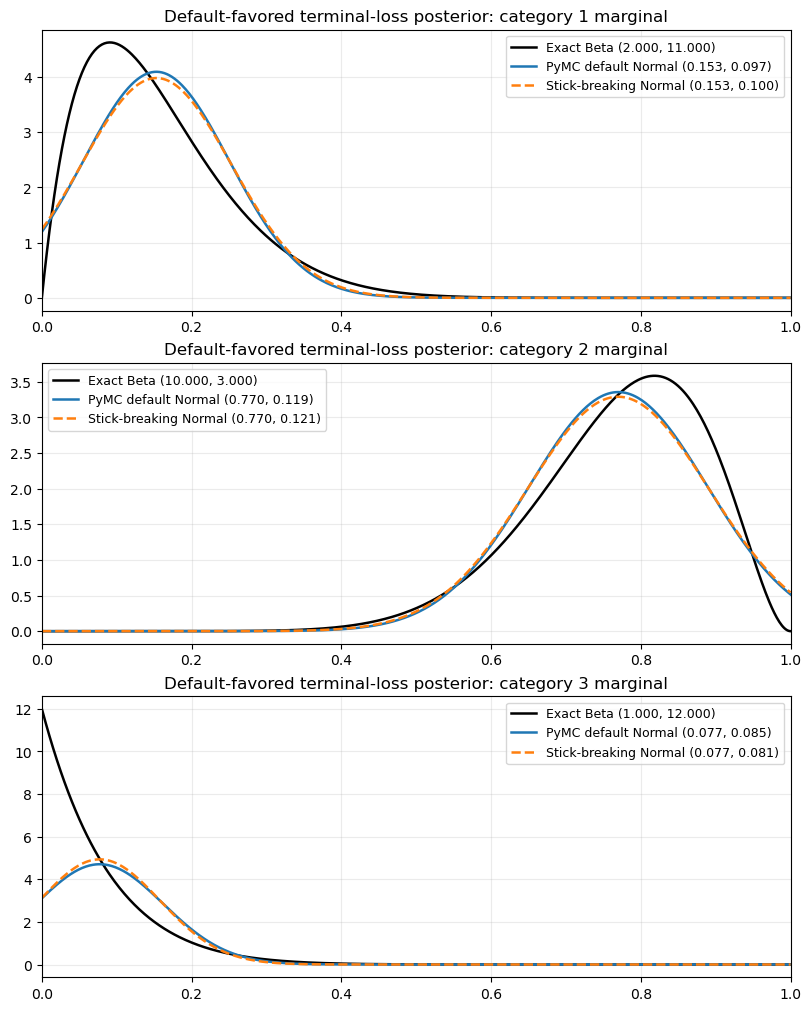

In [10]:
if RUN_FINAL_DIRICHLET_TOYS:
    toy_cases = [
        {
            "name": "Middle-heavy posterior",
            "alpha_prior": [0.3, 3.0, 0.3],
            "obs_counts": [[1, 7, 0], [1, 7, 0], [0, 8, 0]],
            "vi_seed": 5,
            "transport_seed": 202,
            "n_iters": 50_000,
        },
        {
            "name": "Default-favored terminal-loss posterior",
            "alpha_prior": [2.0, 2.0, 1.0],
            "obs_counts": [[0, 8, 0]],
            "vi_seed": 2,
            "transport_seed": 303,
            "n_iters": 50_000,
        },
    ]

    toy_results = {}
    for case in toy_cases:
        print(f"Running {case['name']} ...")
        toy_results[case["name"]] = {
            "default": fit_dirichlet_toy_case(case, "default", n_iters=case["n_iters"]),
            "stickbreaking": fit_dirichlet_toy_case(case, "stickbreaking", n_iters=case["n_iters"]),
            "meta": case,
        }

    for case_name, case_results in toy_results.items():
        meta = case_results["meta"]
        default_res = case_results["default"]
        stick_res = case_results["stickbreaking"]
        exact_alpha_post = default_res["exact_alpha_post"]
        exact_draws = default_res["exact_draws"]

        print(case_name)
        print("alpha_prior:", meta["alpha_prior"])
        print("observed counts:")
        print(default_res["obs_counts"])
        print("vi_seed:", meta["vi_seed"])
        print("underlying posterior:", f"Dirichlet(alpha={np.array2string(exact_alpha_post, precision=4)})")
        print("posterior mean:", np.array2string(default_res["exact_mean"], precision=4))
        print("ADVI iterations:", meta["n_iters"])
        print()

        summary_rows = [
            {
                "transform": "PyMC default",
                "terminal_loss": default_res["final_loss"],
            },
            {
                "transform": "Stick-breaking",
                "terminal_loss": stick_res["final_loss"],
            },
        ]
        print_rows_table(summary_rows)
        loss_winner = "PyMC default" if default_res["final_loss"] < stick_res["final_loss"] else "Stick-breaking"
        print("lower terminal loss:", loss_winner)
        print()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
        for ax in axes:
            draw_simplex(ax)

        simplex_kde_contour(axes[0], exact_draws, color="black", label="Exact Dirichlet posterior")
        simplex_kde_contour(axes[0], default_res["theta_draws"], color="tab:blue", label="PyMC default")
        axes[0].set_title(f"{case_name}: exact vs PyMC default")
        axes[0].legend(loc="lower left", fontsize=9)

        simplex_kde_contour(axes[1], exact_draws, color="black", label="Exact Dirichlet posterior")
        simplex_kde_contour(axes[1], stick_res["theta_draws"], color="tab:orange", label="Stick-breaking")
        axes[1].set_title(f"{case_name}: exact vs stick-breaking")
        axes[1].legend(loc="lower left", fontsize=9)

        plt.show()

        fig, axes = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)
        x = np.linspace(1e-4, 1 - 1e-4, 600)
        alpha0 = np.sum(exact_alpha_post)

        for i, ax in enumerate(axes):
            alpha_i = exact_alpha_post[i]
            beta_i = alpha0 - alpha_i
            exact_beta = beta(alpha_i, beta_i)
            default_std_i = np.sqrt(np.clip(default_res["approx_cov"][i, i], 0.0, None))
            stick_std_i = np.sqrt(np.clip(stick_res["approx_cov"][i, i], 0.0, None))

            ax.plot(x, exact_beta.pdf(x), color="black", linewidth=1.8, label=f"Exact Beta ({alpha_i:.3f}, {beta_i:.3f})")
            ax.plot(
                x,
                norm.pdf(x, loc=default_res["approx_mean"][i], scale=max(default_std_i, 1e-8)),
                color="tab:blue",
                linewidth=1.8,
                label=f"PyMC default Normal ({default_res['approx_mean'][i]:.3f}, {default_std_i:.3f})",
            )
            ax.plot(
                x,
                norm.pdf(x, loc=stick_res["approx_mean"][i], scale=max(stick_std_i, 1e-8)),
                color="tab:orange",
                linewidth=1.8,
                linestyle="--",
                label=f"Stick-breaking Normal ({stick_res['approx_mean'][i]:.3f}, {stick_std_i:.3f})",
            )
            ax.set_title(f"{case_name}: category {i + 1} marginal")
            ax.set_xlim(0, 1)
            ax.grid(alpha=0.25)
            ax.legend(loc="best", fontsize=9)

        plt.show()
else:
    print("Skipping the final Dirichlet toy section. Set RUN_FINAL_DIRICHLET_TOYS = True to run it.")


These final examples stay inside the conjugate Dirichlet-multinomial setting and are now compared using the **terminal ADVI loss** only. The second case is fixed to `alpha_prior = [2, 2, 1]`, `obs_counts = [[0, 8, 0]]`, and `vi_seed = 2`, so the notebook matches the default-favored terminal-loss run directly.
